## Backward Calculation of Implied Probabilities - Start: MAY 2026

In [ ]:
import pandas as pd
import numpy as np

cme_may_2026 = pd.read_csv("../../data/raw/CME/CME_MAY_2026.csv")
cme_may_2026 = cme_may_2026.reset_index(drop = True)
cme_may_2026["time"] = pd.to_datetime(cme_may_2026["time"],unit="s") 

In [2]:
cme_may_2026

,time,open,high,low,close,Volume
0,2025-12-01 17:05:00,96.5350,96.5350,96.5350,96.5350,29
1,2025-12-01 17:08:00,96.5350,96.5350,96.5350,96.5350,804
2,2025-12-01 17:09:00,96.5350,96.5350,96.5350,96.5350,48
3,2025-12-01 17:12:00,96.5350,96.5350,96.5350,96.5350,103
4,2025-12-01 17:15:00,96.5350,96.5350,96.5350,96.5350,230
...,...,...,...,...,...,...
19994,2026-05-29 12:16:00,96.3725,96.3725,96.3725,96.3725,1
19995,2026-05-29 13:02:00,96.3725,96.3725,96.3725,96.3725,1
19996,2026-05-29 15:31:00,96.3700,96.3700,96.3700,96.3700,1000
19997,2026-05-29 15:53:00,96.3700,96.3700,96.3700,96.3700,1000


## CME End: APR 2026

In [ ]:
cme_apr_2026 = pd.read_csv("../../data/raw/CME/CME_APR_2026.csv")
cme_apr_2026 = cme_apr_2026.reset_index(drop = True)
cme_apr_2026["time"] = pd.to_datetime(cme_apr_2026["time"],unit="s") 

In [8]:
cme_apr_2026

,time,open,high,low,close,Volume
0,2025-10-31 17:28:00,96.445,96.445,96.445,96.445,6
1,2025-10-31 17:29:00,96.445,96.445,96.445,96.445,237
2,2025-10-31 18:25:00,96.445,96.445,96.445,96.445,50
3,2025-10-31 18:27:00,96.445,96.445,96.445,96.445,11
4,2025-10-31 18:28:00,96.445,96.445,96.445,96.445,743
...,...,...,...,...,...,...
19994,2026-04-30 15:58:00,96.360,96.360,96.360,96.360,7
19995,2026-04-30 17:36:00,96.360,96.360,96.360,96.360,4
19996,2026-04-30 18:59:00,96.360,96.360,96.360,96.360,1
19997,2026-04-30 20:06:00,96.360,96.360,96.360,96.360,1


## Merge

In [9]:
may = cme_may_2026.copy()
may["time"] = pd.to_datetime(may["time"], unit="s")

if may["time"].dt.tz is None:
    may["time"] = may["time"].dt.tz_localize("UTC")
else:
    may["time"] = may["time"].dt.tz_convert("UTC")

may = may.sort_values("time").set_index("time")
may = may.add_suffix("_may_2026")

apr = cme_apr_2026.copy()
apr["time"] = pd.to_datetime(apr["time"], unit="s")

if apr["time"].dt.tz is None:
    apr["time"] = apr["time"].dt.tz_localize("UTC")
else:
    apr["time"] = apr["time"].dt.tz_convert("UTC")

apr = apr.sort_values("time").set_index("time")
apr = apr.add_suffix("_apr_2026")

In [10]:
final_df = may.join(apr, how="left")

In [11]:
final_df = final_df.dropna()

In [12]:
final_df = final_df.reset_index()

In [13]:
final_df

,time,open_may_2026,high_may_2026,low_may_2026,close_may_2026,Volume_may_2026,open_apr_2026,high_apr_2026,low_apr_2026,close_apr_2026,Volume_apr_2026
0,2025-12-01 17:05:00+00:00,96.535,96.535,96.535,96.535,29,96.485,96.485,96.485,96.485,17.0
1,2025-12-01 17:09:00+00:00,96.535,96.535,96.535,96.535,48,96.485,96.485,96.485,96.485,19.0
2,2025-12-01 17:15:00+00:00,96.535,96.535,96.535,96.535,230,96.485,96.485,96.485,96.485,5.0
3,2025-12-01 17:22:00+00:00,96.535,96.535,96.535,96.535,1,96.485,96.485,96.485,96.485,1366.0
4,2025-12-01 17:40:00+00:00,96.535,96.535,96.535,96.535,1,96.485,96.485,96.485,96.485,8.0
...,...,...,...,...,...,...,...,...,...,...,...
6546,2026-04-30 15:27:00+00:00,96.360,96.360,96.360,96.360,33,96.360,96.360,96.360,96.360,10.0
6547,2026-04-30 15:54:00+00:00,96.360,96.360,96.360,96.360,1000,96.360,96.360,96.360,96.360,7.0
6548,2026-04-30 15:58:00+00:00,96.360,96.360,96.360,96.360,1000,96.360,96.360,96.360,96.360,7.0
6549,2026-04-30 18:59:00+00:00,96.360,96.360,96.360,96.360,9,96.360,96.360,96.360,96.360,1.0


## Calculate Implied Probabilities

In [14]:
meeting_day = 29
days_in_apr = 30

N = meeting_day           
M = days_in_apr - N        

imp_df = pd.DataFrame()
imp_df["time"] = final_df["time"].copy()

imp_df["effr_avg_apr"] = 100 - final_df["close_apr_2026"]
imp_df["effr_avg_may"] = 100 - final_df["close_may_2026"]

imp_df["effr_start_may"] = imp_df["effr_avg_may"]
imp_df["effr_end_apr"] = imp_df["effr_start_may"]
imp_df["volume"] = final_df["Volume_apr_2026"]


In [15]:
imp_df["effr_start_apr"] = (
    imp_df["effr_avg_apr"] - (M / (N + M)) * imp_df["effr_end_apr"]
) / (N / (N + M))

In [16]:
imp_df["delta_effr"] = imp_df["effr_end_apr"] - imp_df["effr_start_apr"]
imp_df["num_hikes"] = imp_df["delta_effr"] / 0.25

imp_df["hikes_floor"] = np.floor(imp_df["num_hikes"])
imp_df["hikes_decimal"] = imp_df["num_hikes"] - imp_df["hikes_floor"]

states = [-4, -3, -2, -1, 0, 1, 2, 3, 4]

state_to_col = {
    -4: "prob_cut_100",
    -3: "prob_cut_75",
    -2: "prob_cut_50",
    -1: "prob_cut_25",
     0: "prob_no_change",
     1: "prob_hike_25",
     2: "prob_hike_50",
     3: "prob_hike_75",
     4: "prob_hike_100"
}

for col in state_to_col.values():
    imp_df[col] = 0.0

for i, row in imp_df.iterrows():
    floor = int(row["hikes_floor"])
    decimal = row["hikes_decimal"]
    
    p_low = 1 - decimal
    p_high = decimal
    
    if floor in state_to_col:
        imp_df.at[i, state_to_col[floor]] += p_low

    if (floor + 1) in state_to_col:
        imp_df.at[i, state_to_col[floor + 1]] += p_high

In [17]:
imp_df["time"] = pd.to_datetime(imp_df["time"], utc=True)

In [18]:
imp_df

,time,effr_avg_apr,effr_avg_may,effr_start_may,effr_end_apr,volume,effr_start_apr,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
0,2025-12-01 17:05:00+00:00,3.515,3.465,3.465,3.465,17.0,3.516724,-0.051724,-0.206897,-1.0,0.793103,0.0,0.0,0.0,0.206897,0.793103,0.0,0.0,0.0,0.0
1,2025-12-01 17:09:00+00:00,3.515,3.465,3.465,3.465,19.0,3.516724,-0.051724,-0.206897,-1.0,0.793103,0.0,0.0,0.0,0.206897,0.793103,0.0,0.0,0.0,0.0
2,2025-12-01 17:15:00+00:00,3.515,3.465,3.465,3.465,5.0,3.516724,-0.051724,-0.206897,-1.0,0.793103,0.0,0.0,0.0,0.206897,0.793103,0.0,0.0,0.0,0.0
3,2025-12-01 17:22:00+00:00,3.515,3.465,3.465,3.465,1366.0,3.516724,-0.051724,-0.206897,-1.0,0.793103,0.0,0.0,0.0,0.206897,0.793103,0.0,0.0,0.0,0.0
4,2025-12-01 17:40:00+00:00,3.515,3.465,3.465,3.465,8.0,3.516724,-0.051724,-0.206897,-1.0,0.793103,0.0,0.0,0.0,0.206897,0.793103,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6546,2026-04-30 15:27:00+00:00,3.640,3.640,3.640,3.640,10.0,3.640000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,1.000000,0.0,0.0,0.0,0.0
6547,2026-04-30 15:54:00+00:00,3.640,3.640,3.640,3.640,7.0,3.640000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,1.000000,0.0,0.0,0.0,0.0
6548,2026-04-30 15:58:00+00:00,3.640,3.640,3.640,3.640,7.0,3.640000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,1.000000,0.0,0.0,0.0,0.0
6549,2026-04-30 18:59:00+00:00,3.640,3.640,3.640,3.640,1.0,3.640000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,1.000000,0.0,0.0,0.0,0.0


## Filter Based on Decision Date


In [19]:
fomc_2026_utc = {
    "January 2026": pd.Timestamp("2026-01-28 19:00:00", tz="UTC"),   # Winter (Standard Time)
    "March 2026": pd.Timestamp("2026-03-18 18:00:00", tz="UTC"),     # Summer (Daylight Saving)
    "April 2026": pd.Timestamp("2026-04-29 18:00:00", tz="UTC"),     # Summer (Daylight Saving)
    "June 2026": pd.Timestamp("2026-06-17 18:00:00", tz="UTC"),      # Summer (Daylight Saving)
    "July 2026": pd.Timestamp("2026-07-29 18:00:00", tz="UTC"),      # Summer (Daylight Saving)1
    "September 2026": pd.Timestamp("2026-09-16 18:00:00", tz="UTC"), # Summer (Daylight Saving)
    "October 2026": pd.Timestamp("2026-10-28 18:00:00", tz="UTC"),   # Summer (Daylight Saving)
    "December 2026": pd.Timestamp("2026-12-09 19:00:00", tz="UTC"),  # Winter (Standard Time)
}

In [20]:
def filter_up_to_announcement(df, announcement_dict):

    if df.empty:
        return df
    last_timestamp = df["time"].iloc[-1]
    last_month_year = last_timestamp.strftime("%B %Y")

    if last_month_year in announcement_dict:
        cutoff_time = announcement_dict[last_month_year]
        filtered_df = df[df["time"] <= cutoff_time]
        return filtered_df
    else:
        print(
            f"Warning: '{last_month_year}' not found in the announcement dictionary"
        )
        return df

In [21]:
imp_df_fil = filter_up_to_announcement(imp_df,fomc_2026_utc)

In [22]:
imp_df_fil

,time,effr_avg_apr,effr_avg_may,effr_start_may,effr_end_apr,volume,effr_start_apr,delta_effr,num_hikes,hikes_floor,hikes_decimal,prob_cut_100,prob_cut_75,prob_cut_50,prob_cut_25,prob_no_change,prob_hike_25,prob_hike_50,prob_hike_75,prob_hike_100
0,2025-12-01 17:05:00+00:00,3.515,3.4650,3.4650,3.4650,17.0,3.516724,-0.051724,-0.206897,-1.0,0.793103,0.0,0.0,0.0,0.206897,0.793103,0.000000,0.0,0.0,0.0
1,2025-12-01 17:09:00+00:00,3.515,3.4650,3.4650,3.4650,19.0,3.516724,-0.051724,-0.206897,-1.0,0.793103,0.0,0.0,0.0,0.206897,0.793103,0.000000,0.0,0.0,0.0
2,2025-12-01 17:15:00+00:00,3.515,3.4650,3.4650,3.4650,5.0,3.516724,-0.051724,-0.206897,-1.0,0.793103,0.0,0.0,0.0,0.206897,0.793103,0.000000,0.0,0.0,0.0
3,2025-12-01 17:22:00+00:00,3.515,3.4650,3.4650,3.4650,1366.0,3.516724,-0.051724,-0.206897,-1.0,0.793103,0.0,0.0,0.0,0.206897,0.793103,0.000000,0.0,0.0,0.0
4,2025-12-01 17:40:00+00:00,3.515,3.4650,3.4650,3.4650,8.0,3.516724,-0.051724,-0.206897,-1.0,0.793103,0.0,0.0,0.0,0.206897,0.793103,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6538,2026-04-29 17:35:00+00:00,3.640,3.6425,3.6425,3.6425,170.0,3.639914,0.002586,0.010345,0.0,0.010345,0.0,0.0,0.0,0.000000,0.989655,0.010345,0.0,0.0,0.0
6539,2026-04-29 17:48:00+00:00,3.640,3.6400,3.6400,3.6400,12.0,3.640000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,1.000000,0.000000,0.0,0.0,0.0
6540,2026-04-29 17:49:00+00:00,3.640,3.6400,3.6400,3.6400,3.0,3.640000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,1.000000,0.000000,0.0,0.0,0.0
6541,2026-04-29 17:58:00+00:00,3.640,3.6425,3.6425,3.6425,67.0,3.639914,0.002586,0.010345,0.0,0.010345,0.0,0.0,0.0,0.000000,0.989655,0.010345,0.0,0.0,0.0


## Visualization

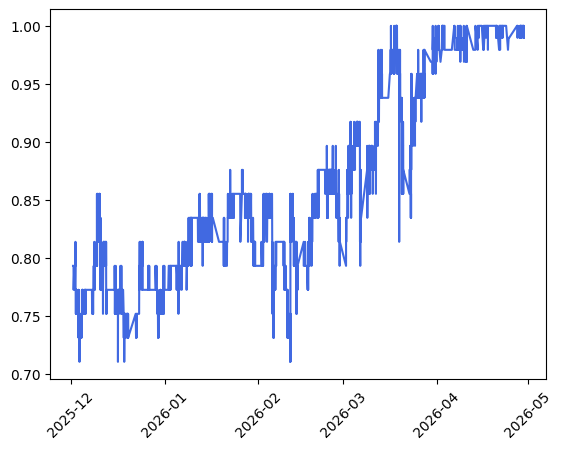

In [23]:
import matplotlib.pyplot as plt

plt.plot(imp_df_fil["time"],imp_df_fil['prob_no_change'], color='royalblue', linewidth=1.5)
plt.xticks(rotation=45)
plt.show()

## Export Data as CSV

In [24]:
import os
DATA_DIR = "../../data/processed/CME_implied_probabilities"
filename = "CME_IMP_APR_2026.csv"
path = os.path.join(DATA_DIR, filename)
imp_df_fil.to_csv(path,index=False)